# Project 1: Vector Operations Visualiser

Create 2D and 3D visualisations of vector
addition, dot products, and cosine similarity
using Matplotlib. Animate a 'sensor journey' —
plot 50 sensor readings as points in 2D feature
space (temperature vs. current) and show how 
a decision boundary line (a weight vector)
separates normal from anomalous readings.

## Skills: NumPy linalg, Matplotlib 3D, vector geometry

Cosine similarity: 0.6139


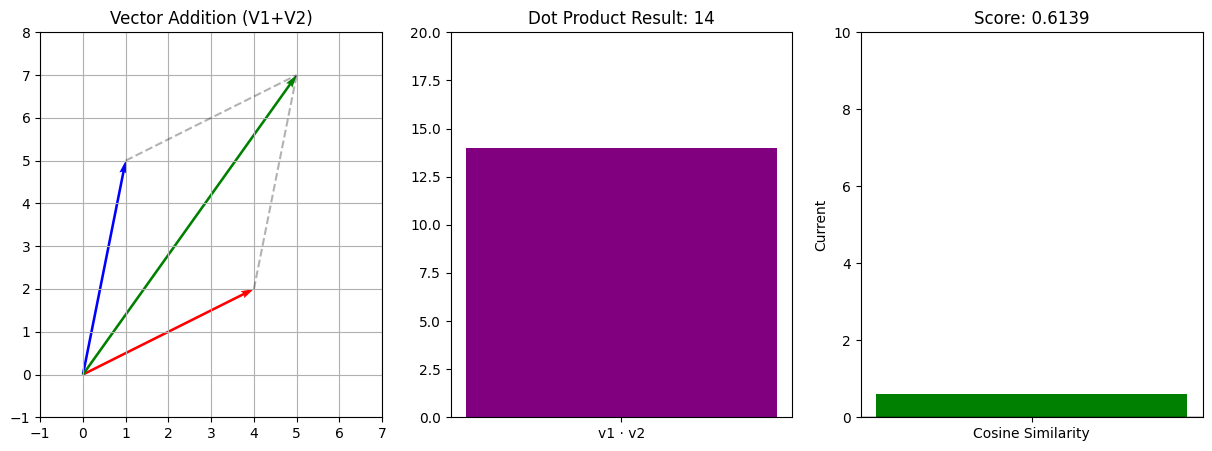

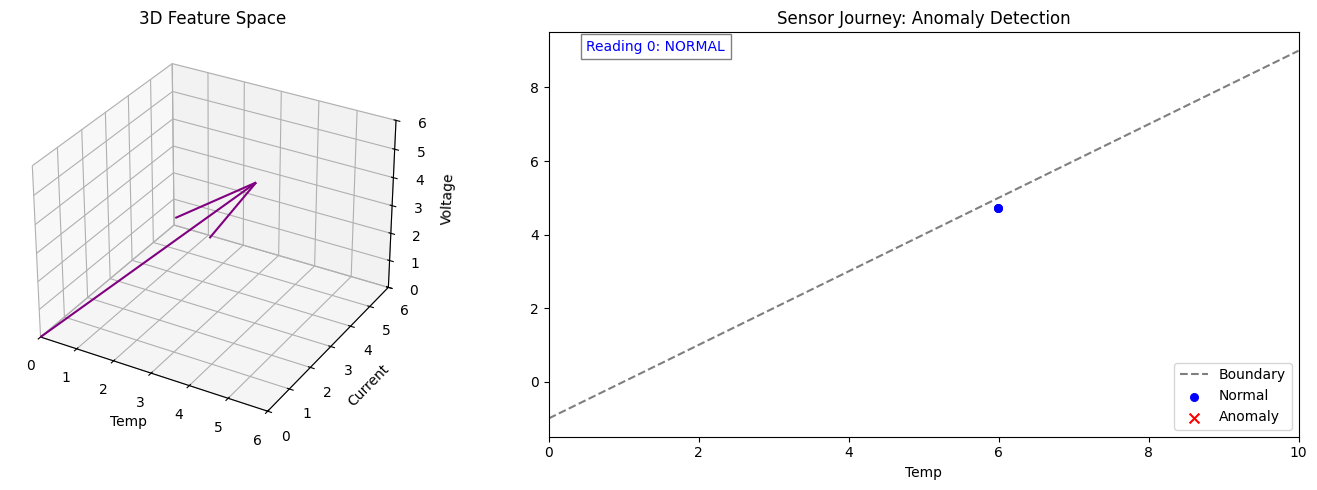

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D

# --- 1. SETUP DATA ---
np.random.seed(42)
# Sensor readings: 50 points (Temperature, Current)
readings = np.random.randn(50, 2) * 2 + 5 
weights = np.array([1, -1])  # Weight vector for decision boundary
bias = -1

# Initialize Figure with subplots
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131)  # 2D Vector Ops
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)
fig2 = plt.figure(figsize= (15, 5))
ax4 = fig2.add_subplot(121, projection='3d')  # 3D Feature Space
ax5 = fig2.add_subplot(122)  # Animated Sensor Journey

# --- 2. STATIC PLOTS (Vector Ops & 3D Space) ---

# Subplot 1: 2D Vector Addition
v1, v2 = np.array([4, 2]), np.array([1, 5])
v_sum = v1 + v2
ax1.quiver([0, 0, 0], [0, 0, 0], [v1[0], v2[0], v_sum[0]], [v1[1], v2[1], v_sum[1]], 
           color=['r', 'b', 'g'], angles='xy', scale_units='xy', scale=1, label=['V1', 'V2', 'Sum'])
ax1.plot([v1[0], v_sum[0]], [v1[1], v_sum[1]], 'k--', alpha=0.3)
ax1.plot([v2[0], v_sum[0]], [v2[1], v_sum[1]], 'k--', alpha=0.3)
ax1.set_title("Vector Addition (V1+V2)")
ax1.set_xlim(-1, 7), ax1.set_ylim(-1, 8), ax1.grid(True)

#subplot 2: 2D vector dot product
dot = np.dot(v1, v2)
ax2.bar(['v1 · v2'], [dot], color='purple')
ax2.set_ylim(0, 20)
ax2.set_title(f'Dot Product Result: {dot}')

#subplot 3: 2D cosine similaties
cos_sim = dot/ (np.linalg.norm(v1) * np.linalg.norm(v2))
colors = ['green' if cos_sim > 0.5 else 'orange']
ax3.bar(['Cosine Similarity'], [cos_sim], color=colors, width=0.5)

ax3.set_ylim(-1, 1) # Cosine similarity range
ax3.axhline(0, color='black', lw=1)
ax3.set_title(f"Score: {cos_sim:.4f}")
print(f"Cosine similarity: {cos_sim:.4f}")

# Subplot 2: 3D Visualization
vec_3d = np.array([4, 3, 5])
ax4.quiver(0, 0, 0, vec_3d[0], vec_3d[1], vec_3d[2], color='purple')
ax4.set_xlim([0, 6]), ax4.set_ylim([0, 6]), ax4.set_zlim([0, 6])
ax4.set_xlabel('Temp'), ax4.set_ylabel('Current'), ax4.set_zlabel('Voltage')
ax4.set_title("3D Feature Space")

# --- 3. ANIMATION SETUP (Sensor Journey) ---

ax5.set_xlim(0, 10), ax3.set_ylim(0, 10)
ax5.set_title("Sensor Journey: Anomaly Detection")
ax5.set_xlabel("Temp"), ax3.set_ylabel("Current")

# Plot Decision Boundary (Line where w.x + b = 0)
x_vals = np.linspace(0, 10, 100)
y_vals = x_vals + bias
ax5.plot(x_vals, y_vals, 'k--', alpha=0.5, label="Boundary")

scatter_normal = ax5.scatter([], [], c='blue', label='Normal', s=30)
scatter_anomaly = ax5.scatter([], [], c='red', label='Anomaly', s=50, marker='x')
text_label = ax5.text(0.5, 9, "", fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

normal_list, anomaly_list = [], []

def update(i):
    point = readings[i]
    # The Math: Dot Product determines the side of the boundary
    score = np.dot(weights, point) + bias
    
    if score > 0:
        normal_list.append(point)
    else:
        anomaly_list.append(point)
    
    if normal_list: scatter_normal.set_offsets(normal_list)
    if anomaly_list: scatter_anomaly.set_offsets(anomaly_list)
        
    status = "NORMAL" if score > 0 else "ANOMALY"
    text_label.set_text(f"Reading {i}: {status}")
    text_label.set_color("blue" if score > 0 else "red")
    
    return scatter_normal, scatter_anomaly, text_label

ani = FuncAnimation(fig, update, frames=len(readings), interval=150, blit=True)

plt.tight_layout()
plt.legend(loc='lower right')
plt.show()